<a href="https://colab.research.google.com/github/imunell/practice1_github/blob/main/%D0%9C%D0%BE%D0%B4%D0%B5%D0%BB%D1%8C%20%D0%BA%D0%B2%D0%B0%D0%BD%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%BE%D0%B9%20%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D0%B8%20%D0%BD%D0%B0%20%D0%BF%D1%80%D0%B8%D0%BC%D0%B5%D1%80%D0%B5%20%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85%20%D0%BE%20%D1%81%D1%82%D0%BE%D0%B8%D0%BC%D0%BE%D1%81%D1%82%D0%B8%20%D0%B0%D0%B2%D1%82%D0%BE%D0%BC%D0%BE%D0%B1%D0%B8%D0%BB%D0%B5%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
install.packages(c("quantreg", "tidyverse", "corrplot"))

library(tidyverse)
library(quantreg)

df <- read.csv("car_price.csv")
#предобработка
df_clean <- df %>%
  select(-Car.ID, -Model) %>%
  mutate(Age = 2026 - Year,
         Brand = as.factor(Brand),
         Fuel.Type = as.factor(Fuel.Type),
         Transmission = as.factor(Transmission),
         Condition = as.factor(Condition)) %>%
  select(-Year)

#вывод статистики
summary(df_clean[, c("Price", "Engine.Size", "Mileage", "Age")])

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



     Price        Engine.Size       Mileage            Age       
 Min.   : 5011   Min.   :1.000   Min.   :    15   Min.   : 3.00  
 1st Qu.:28908   1st Qu.:2.200   1st Qu.: 71832   1st Qu.: 8.00  
 Median :53485   Median :3.400   Median :149085   Median :14.00  
 Mean   :52638   Mean   :3.465   Mean   :149750   Mean   :14.37  
 3rd Qu.:75839   3rd Qu.:4.700   3rd Qu.:225990   3rd Qu.:21.00  
 Max.   :99983   Max.   :6.000   Max.   :299967   Max.   :26.00  

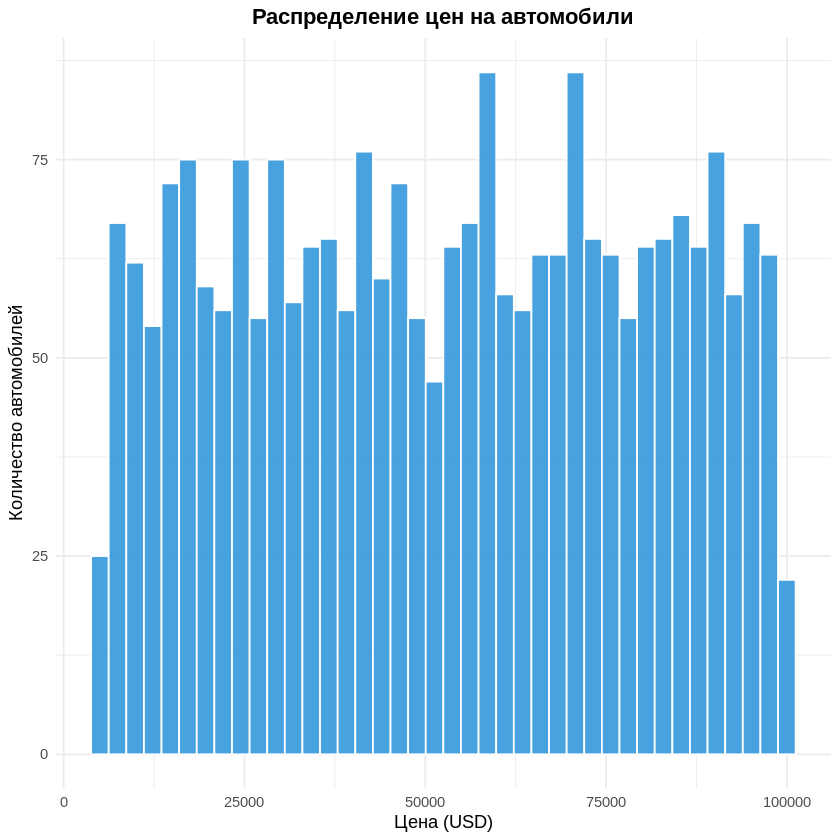

In [ ]:
#гистограмма распределения цен
ggplot(df_clean, aes(x = Price)) +
  geom_histogram(bins = 40, fill = "#3498db", color = "white", alpha = 0.9) +
  labs(title = "Распределение цен на автомобили",
       x = "Цена (USD)", y = "Количество автомобилей") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"))

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'


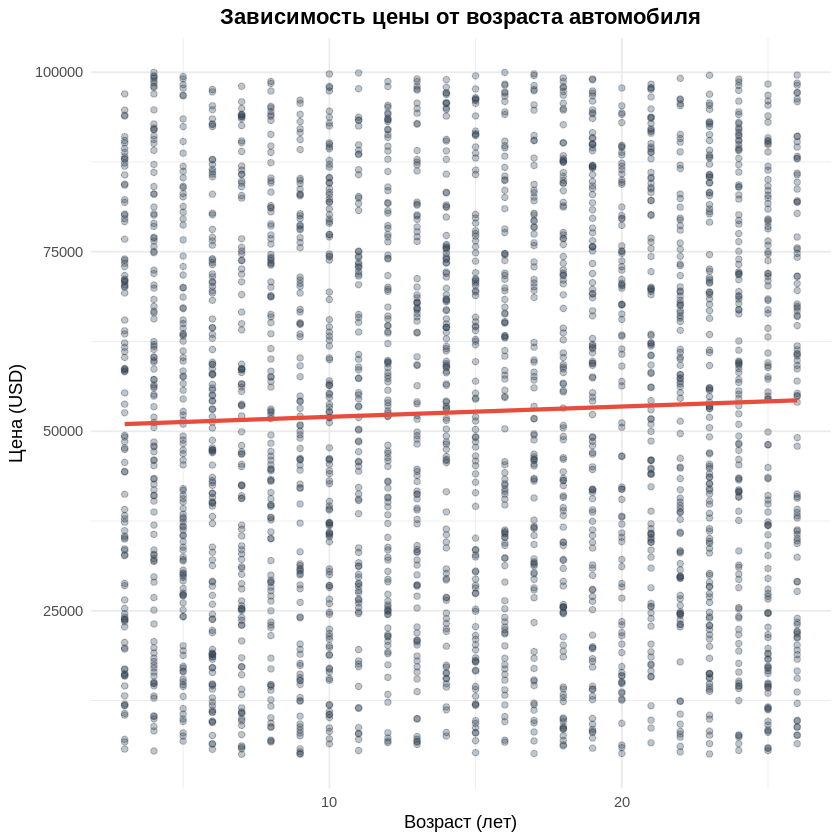

In [ ]:
#зависимость цены от возраста
ggplot(df_clean, aes(x = Age, y = Price)) +
  geom_point(alpha = 0.3, color = "#2c3e50") +
  geom_smooth(method = "lm", se = FALSE, color = "#e74c3c", size = 1.2) +
  labs(title = "Зависимость цены от возраста автомобиля",
       x = "Возраст (лет)", y = "Цена (USD)") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"))

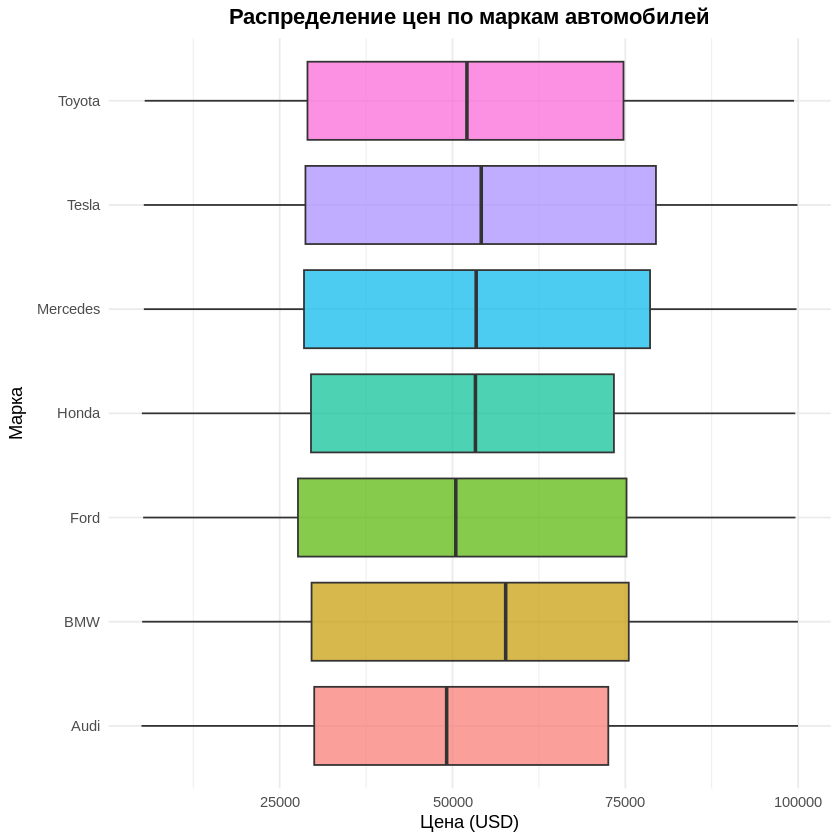

In [ ]:
#распределение цен по маркам
ggplot(df_clean, aes(x = Brand, y = Price, fill = Brand)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Распределение цен по маркам автомобилей",
       x = "Марка", y = "Цена (USD)") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"),
        legend.position = "none") +
  coord_flip()

In [ ]:
#квантильная регрессия

formula <- Price ~ Age + Mileage + Engine.Size + Brand #формула модели

#модель для 10% перцентиля (дешевые авто)
model_q10 <- rq(formula, data = df_clean, tau = 0.1)

#модель для 50% перцентиля (медиана)
model_q50 <- rq(formula, data = df_clean, tau = 0.5)

#модель для 90% перцентиля (дорогие авто)
model_q90 <- rq(formula, data = df_clean, tau = 0.9)

cat("Модель для 10% перцентиля (дешевые авто) \n")
summary(model_q10)

cat("\nМодель для 50% перцентиля (медиана) \n")
summary(model_q50)

cat("\nМодель для 90% перцентиля (дорогие авто) \n")
summary(model_q90)

Warning message in rq.fit.br(x, y, tau = tau, ...):
“Solution may be nonunique”


Модель для 10% перцентиля (дешевые авто) 



Call: rq(formula = formula, tau = 0.1, data = df_clean)

tau: [1] 0.1

Coefficients:
              Value       Std. Error  t value     Pr(>|t|)   
(Intercept)   12834.08706  2476.31870     5.18273     0.00000
Age              44.32992    69.23600     0.64027     0.52205
Mileage          -0.00065     0.00545    -0.11962     0.90479
Engine.Size     451.56301   340.63311     1.32566     0.18507
BrandBMW       -297.82234  2063.40622    -0.14434     0.88525
BrandFord      1539.52248  2205.85284     0.69793     0.48529
BrandHonda     1732.35983  2109.82843     0.82109     0.41167
BrandMercedes  -753.28325  2616.82269    -0.28786     0.77348
BrandTesla      495.11781  1970.54897     0.25126     0.80163
BrandToyota    -596.88247  1991.77477    -0.29967     0.76445


Модель для 50% перцентиля (медиана) 



Call: rq(formula = formula, tau = 0.5, data = df_clean)

tau: [1] 0.5

Coefficients:
              Value       Std. Error  t value     Pr(>|t|)   
(Intercept)   46940.11730  4147.29096    11.31826     0.00000
Age             272.60965   131.22815     2.07737     0.03787
Mileage          -0.00095     0.01045    -0.09104     0.92747
Engine.Size      44.98044   636.73552     0.07064     0.94369
BrandBMW       6841.63245  3356.96169     2.03804     0.04165
BrandFord       316.15138  3798.89579     0.08322     0.93368
BrandHonda     2730.17660  2984.81751     0.91469     0.36044
BrandMercedes  2614.77430  3696.00618     0.70746     0.47935
BrandTesla     3773.38784  3586.06331     1.05224     0.29279
BrandToyota     809.35912  3378.18896     0.23958     0.81067


Модель для 90% перцентиля (дорогие авто) 



Call: rq(formula = formula, tau = 0.9, data = df_clean)

tau: [1] 0.9

Coefficients:
              Value       Std. Error  t value     Pr(>|t|)   
(Intercept)   93156.93159  2392.00735    38.94509     0.00000
Age              75.16151    71.28672     1.05435     0.29182
Mileage          -0.00592     0.00540    -1.09792     0.27234
Engine.Size    -336.99845   340.11375    -0.99084     0.32186
BrandBMW      -1077.55931  1936.20846    -0.55653     0.57790
BrandFord     -2562.92553  2247.90636    -1.14014     0.25434
BrandHonda    -5001.32990  2163.35691    -2.31184     0.02087
BrandMercedes  -983.61993  2019.75897    -0.48700     0.62630
BrandTesla    -2560.73302  1723.30212    -1.48595     0.13742
BrandToyota   -2947.83792  1836.94517    -1.60475     0.10868

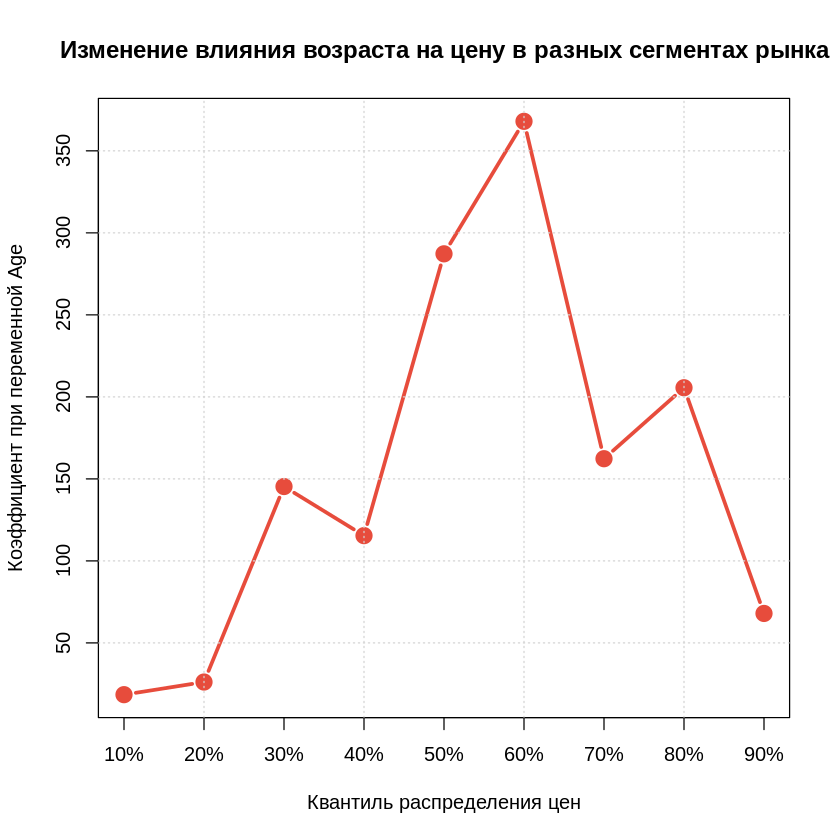

In [ ]:
#график изменения коэффициента по квантилям

qs <- seq(0.1, 0.9, by = 0.1)#последовательность квантилей
coef_age <- sapply(qs, function(tau) {
  coef(rq(Price ~ Age, data = df_clean, tau = tau))[2]
})

plot(qs, coef_age, type = "b",
     col = "#e74c3c", lwd = 3, pch = 19, cex = 1.5,
     main = "Изменение влияния возраста на цену в разных сегментах рынка",
     xlab = "Квантиль распределения цен",
     ylab = "Коэффициент при переменной Age",
     xaxt = "n")
axis(1, at = qs, labels = paste0(qs*100, "%"))
abline(h = 0, lty = 2, col = "gray")
grid()



Smoothing formula not specified. Using: y ~ x
Smoothing formula not specified. Using: y ~ x
Smoothing formula not specified. Using: y ~ x


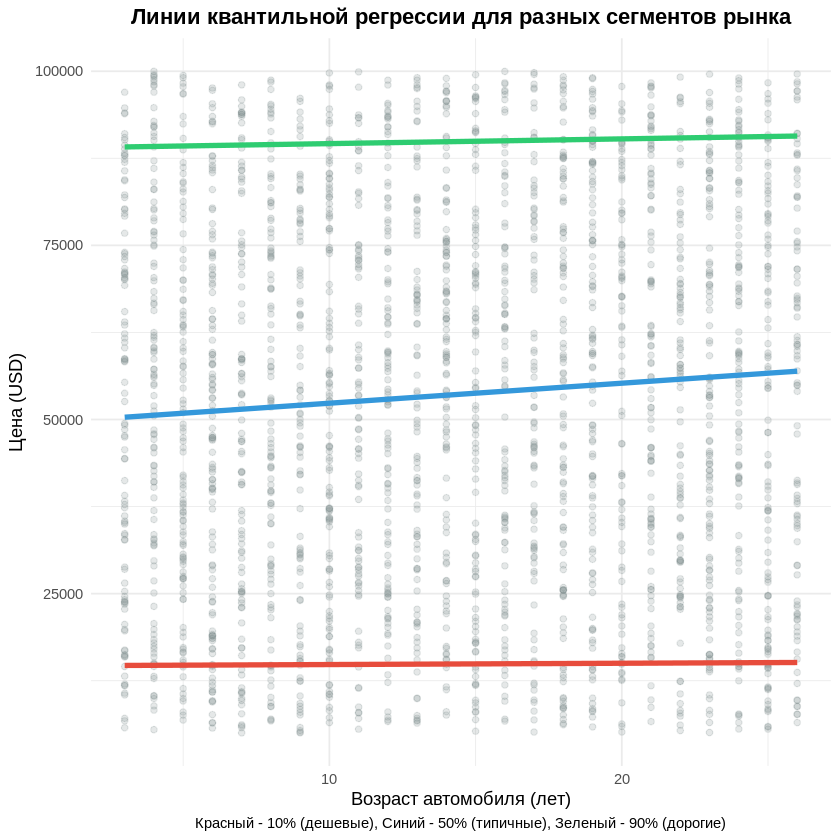

In [ ]:
#визуализация линий квантильной регрессии

ggplot(df_clean, aes(x = Age, y = Price)) +
  geom_point(alpha = 0.2, color = "#7f8c8d") +
  geom_quantile(quantiles = 0.1, color = "#e74c3c", size = 1.5) +
  geom_quantile(quantiles = 0.5, color = "#3498db", size = 1.5) +
  geom_quantile(quantiles = 0.9, color = "#2ecc71", size = 1.5) +
  labs(title = "Линии квантильной регрессии для разных сегментов рынка",
       x = "Возраст автомобиля (лет)", y = "Цена (USD)",
       caption = "Красный - 10% (дешевые), Синий - 50% (типичные), Зеленый - 90% (дорогие)") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"),
        plot.caption = element_text(hjust = 0.5))

In [ ]:
# Проверка возраста (исправленный код)
# Посмотрим первые 10 строк с годом (из исходных данных) и рассчитанным возрастом
df_check <- df %>%
  select(Year, Price) %>%
  mutate(Age_calculated = 2026 - Year) %>%
  head(10)

print(df_check)

   Year    Price Age_calculated
1  2016 26613.92             10
2  2018 14679.61              8
3  2013 44402.61             13
4  2011 86374.33             15
5  2009 73577.10             17
6  2019 88969.76              7
7  2020 63498.75              6
8  2017 17381.19              9
9  2023 15905.62              3
10 2010  9560.22             16


In [ ]:
#проверка статических гипотез

#t-тест: сравнение цен в зависимости от типа трансмиссии
t_test_result <- t.test(Price ~ Transmission, data = df_clean)
cat("t-тест (Automatic vs Manual) \n")
print(t_test_result)

#ANOVA: сравнение цен между разными марками
anova_result <- aov(Price ~ Brand, data = df_clean)
cat("\nANOVA (сравнение цен по маркам) \n")
summary(anova_result)

#Хи-квадрат тест: связь между типом топлива и типом трансмиссии
chisq_result <- chisq.test(table(df_clean$Fuel.Type, df_clean$Transmission))
cat("\nХи-квадрат тест (Fuel.Type vs Transmission) \n")
print(chisq_result)

t-тест (Automatic vs Manual) 

	Welch Two Sample t-test

data:  Price by Transmission
t = 0.093898, df = 2484.1, p-value = 0.9252
alternative hypothesis: true difference in means between group Automatic and group Manual is not equal to 0
95 percent confidence interval:
 -2039.353  2244.484
sample estimates:
mean in group Automatic    mean in group Manual 
               52691.68                52589.12 


ANOVA (сравнение цен по маркам) 


              Df    Sum Sq   Mean Sq F value Pr(>F)
Brand          6 1.968e+09 328006162    0.44  0.853
Residuals   2493 1.860e+12 746066270               


Хи-квадрат тест (Fuel.Type vs Transmission) 

	Pearson's Chi-squared test

data:  table(df_clean$Fuel.Type, df_clean$Transmission)
X-squared = 2.3819, df = 3, p-value = 0.497



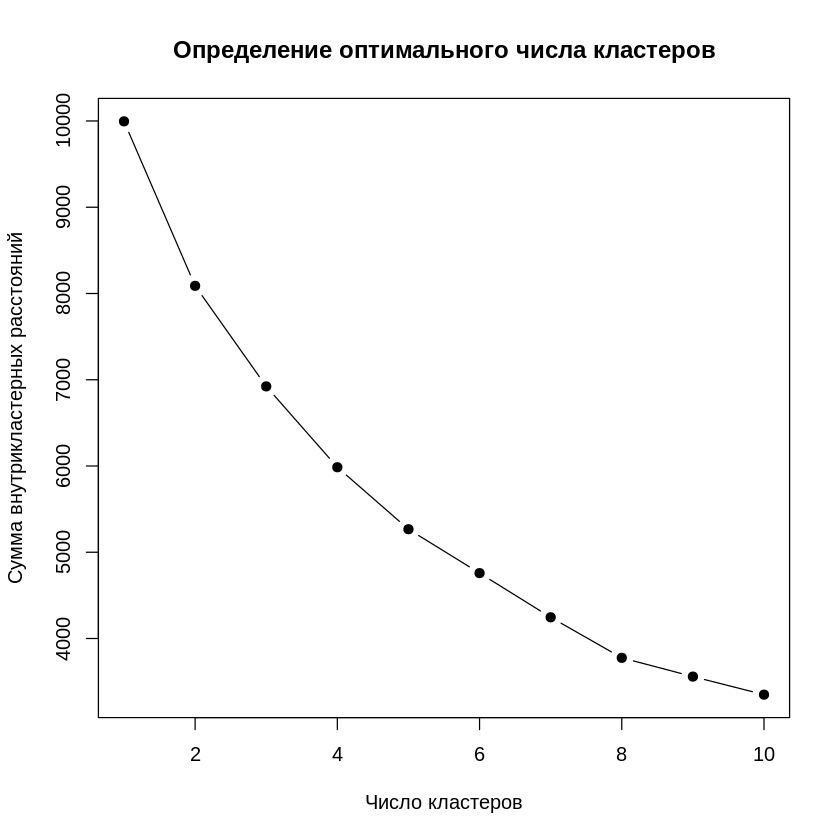

Центры кластеров (стандартизованные):
         Price        Age    Mileage Engine.Size
1 -0.172317209 -0.9764215  0.4948585 -0.03778851
2  0.186247911  0.8717512  0.7386429 -0.05298375
3 -0.004557084  0.1280487 -1.0541676  0.07763193

Распределение автомобилей по кластерам:



  1   2   3 
809 771 920 

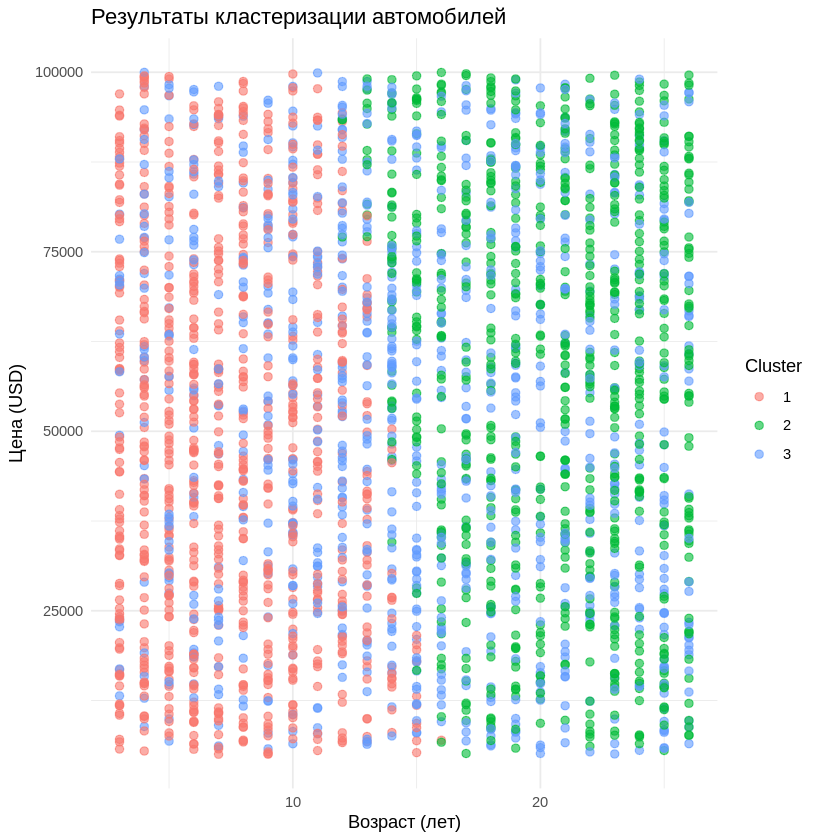

In [ ]:
#кластеризация (k-means)

cluster_data <- df_clean %>%
  select(Price, Age, Mileage, Engine.Size) %>%
  scale()
wss <- sapply(1:10, function(k) {
  kmeans(cluster_data, centers = k, nstart = 25)$tot.withinss
})
plot(1:10, wss, type = "b", pch = 19,
     main = "Определение оптимального числа кластеров",
     xlab = "Число кластеров", ylab = "Сумма внутрикластерных расстояний")

set.seed(123)
kmeans_result <- kmeans(cluster_data, centers = 3, nstart = 25)
df_clean$Cluster <- as.factor(kmeans_result$cluster)

ggplot(df_clean, aes(x = Age, y = Price, color = Cluster)) +
  geom_point(alpha = 0.6, size = 2) +
  labs(title = "Результаты кластеризации автомобилей",
       x = "Возраст (лет)", y = "Цена (USD)") +
  theme_minimal()

cat("Центры кластеров (стандартизованные):\n")
print(kmeans_result$centers)
cat("\nРаспределение автомобилей по кластерам:\n")
table(df_clean$Cluster)

,Price,Age,Mileage,Engine.Size
Price,1.000,0.037,-0.009,-0.004
Age,0.037,1.000,-0.002,-0.012
Mileage,-0.009,-0.002,1.000,-0.016
Engine.Size,-0.004,-0.012,-0.016,1.000


corrplot 0.95 loaded



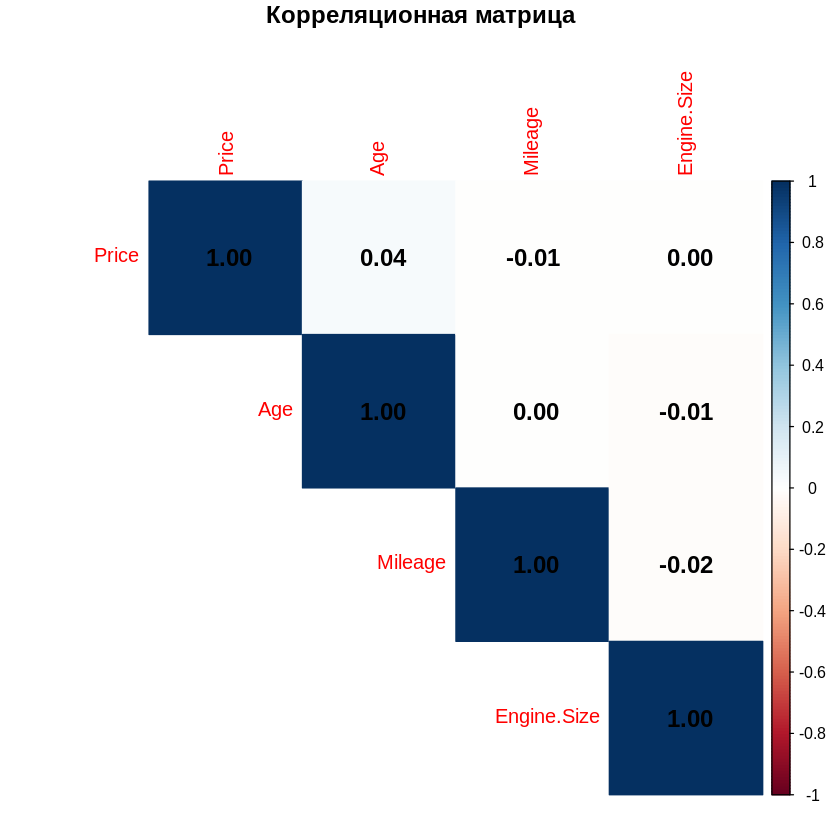

In [ ]:
4

Количество выбросов 
Price (цена): 0 
Age (возраст): 0 
Mileage (пробег): 0 
Engine.Size (объем двигателя): 0 


`geom_smooth()` using formula = 'y ~ x'


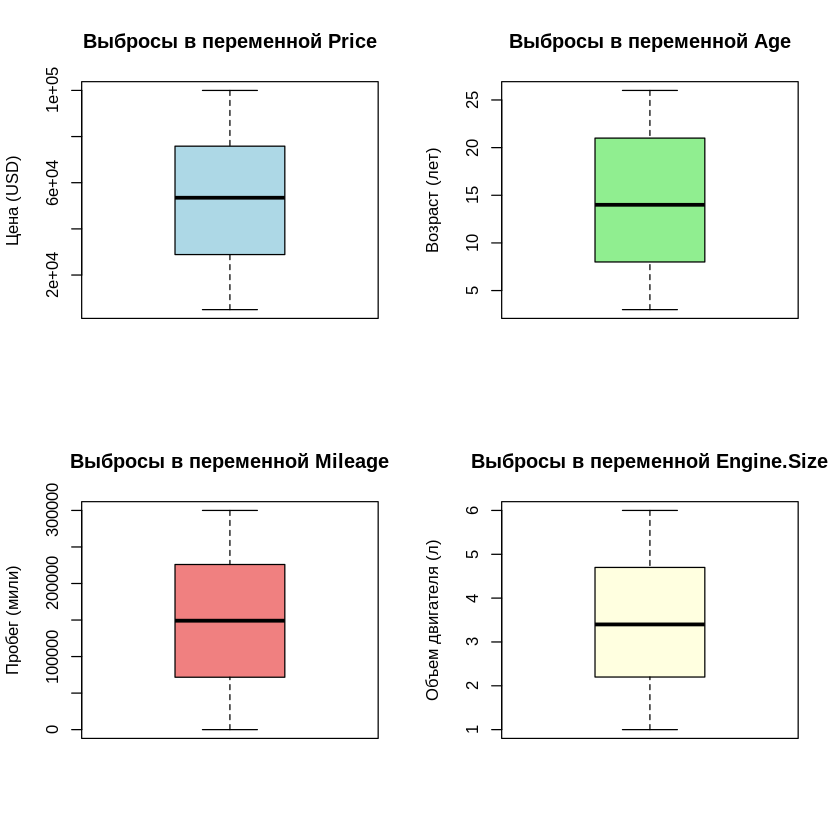

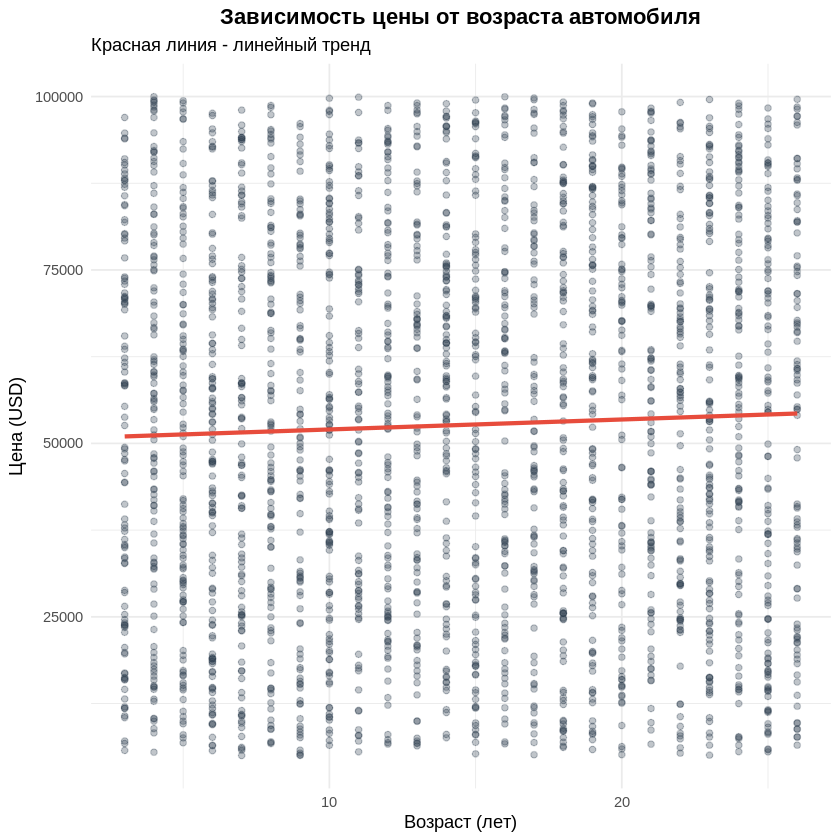

In [ ]:
#выявление выбросов и трендов

library(tidyverse)
library(ggplot2)

#функция для подсчета выбросов
count_outliers <- function(x) {
  Q1 <- quantile(x, 0.25, na.rm = TRUE)
  Q3 <- quantile(x, 0.75, na.rm = TRUE)
  IQR <- Q3 - Q1
  lower_bound <- Q1 - 1.5 * IQR
  upper_bound <- Q3 + 1.5 * IQR
  return(sum(x < lower_bound | x > upper_bound, na.rm = TRUE))
}

#подсчет выбросов для каждой переменной
cat("Количество выбросов \n")
cat("Price (цена):", count_outliers(df_clean$Price), "\n")
cat("Age (возраст):", count_outliers(df_clean$Age), "\n")
cat("Mileage (пробег):", count_outliers(df_clean$Mileage), "\n")
cat("Engine.Size (объем двигателя):", count_outliers(df_clean$Engine.Size), "\n")

#визуализация выбросов с помощью boxplot
par(mfrow = c(2, 2))
boxplot(df_clean$Price,
        main = "Выбросы в переменной Price",
        ylab = "Цена (USD)",
        col = "lightblue")
boxplot(df_clean$Age,
        main = "Выбросы в переменной Age",
        ylab = "Возраст (лет)",
        col = "lightgreen")
boxplot(df_clean$Mileage,
        main = "Выбросы в переменной Mileage",
        ylab = "Пробег (мили)",
        col = "lightcoral")
boxplot(df_clean$Engine.Size,
        main = "Выбросы в переменной Engine.Size",
        ylab = "Объем двигателя (л)",
        col = "lightyellow")
par(mfrow = c(1, 1))

#график зависимости цены от возраста с линейным трендом
ggplot(df_clean, aes(x = Age, y = Price)) +
  geom_point(alpha = 0.3, color = "#2c3e50") +
  geom_smooth(method = "lm", se = FALSE, color = "#e74c3c", size = 1.2) +
  labs(title = "Зависимость цены от возраста автомобиля",
       subtitle = "Красная линия - линейный тренд",
       x = "Возраст (лет)",
       y = "Цена (USD)") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"))

In [ ]:
#описательная статистика

numeric_vars <- df_clean[, c("Price", "Age", "Mileage", "Engine.Size")]

cat("Средние значения\n")
colMeans(numeric_vars, na.rm = TRUE)
cat("\nДисперсия\n")
apply(numeric_vars, 2, var, na.rm = TRUE)
cat("\nСтандартное отклонение\n")
apply(numeric_vars, 2, sd, na.rm = TRUE)

Средние значения


Price          Age      Mileage  Engine.Size 
 52638.02253     14.37320 149749.84480      3.46524


Дисперсия


Price          Age      Mileage  Engine.Size 
7.450625e+08 4.888388e+01 7.729918e+09 2.050776e+00


Стандартное отклонение


Price          Age      Mileage  Engine.Size 
27295.833455     6.991700 87919.952034     1.432053

In [ ]:
install.packages("tidyverse")
install.packages("quantreg")
install.packages("corrplot")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(tidyverse)
library(quantreg)
library(corrplot)

df <- read.csv("car_price.csv")
df_clean <- df %>%
  select(-Car.ID, -Model) %>%
  mutate(Age = 2026 - Year,
         Brand = as.factor(Brand),
         Fuel.Type = as.factor(Fuel.Type),
         Transmission = as.factor(Transmission),
         Condition = as.factor(Condition)) %>%
  select(-Year)

     Price        Engine.Size       Mileage            Age       
 Min.   : 5011   Min.   :1.000   Min.   :    15   Min.   : 3.00  
 1st Qu.:28908   1st Qu.:2.200   1st Qu.: 71832   1st Qu.: 8.00  
 Median :53485   Median :3.400   Median :149085   Median :14.00  
 Mean   :52638   Mean   :3.465   Mean   :149750   Mean   :14.37  
 3rd Qu.:75839   3rd Qu.:4.700   3rd Qu.:225990   3rd Qu.:21.00  
 Max.   :99983   Max.   :6.000   Max.   :299967   Max.   :26.00  

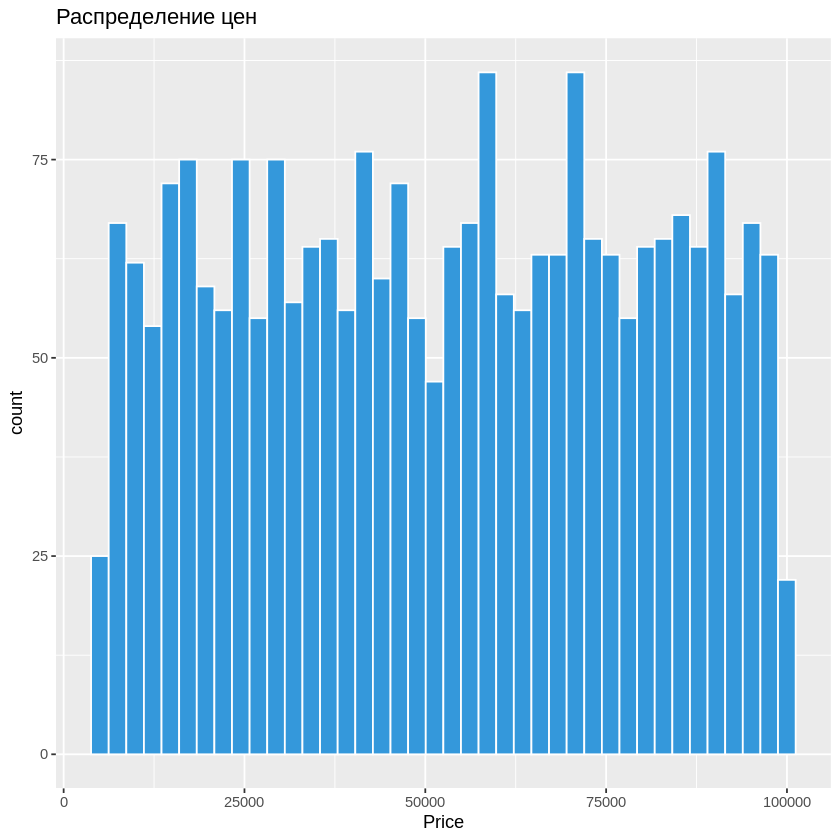

In [ ]:
summary(df_clean[, c("Price", "Engine.Size", "Mileage", "Age")])

ggplot(df_clean, aes(x = Price)) +
  geom_histogram(bins = 40, fill = "#3498db", color = "white") +
  labs(title = "Распределение цен")

In [ ]:
# Загрузка библиотек
install.packages("writexl")
library(tidyverse)
library(writexl)

# Если df_clean уже есть, просто сохраняем
write_xlsx(df_clean, "cars_data_cleaned.xlsx")

# Проверка: посмотреть первые строки
head(df_clean)

# Скачать файл (в Colab слева появится файл → нажмите три точки → Download)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



,Brand,Engine.Size,Fuel.Type,Transmission,Mileage,Condition,Price,Age
,<fct>,<dbl>,<fct>,<fct>,<int>,<fct>,<dbl>,<dbl>
1,Tesla,2.3,Petrol,Manual,114832,New,26613.92,10
2,BMW,4.4,Electric,Manual,143190,Used,14679.61,8
3,Audi,4.5,Electric,Manual,181601,New,44402.61,13
4,Tesla,4.1,Diesel,Automatic,68682,New,86374.33,15
5,Ford,2.6,Diesel,Manual,223009,Like New,73577.10,17
6,Audi,2.4,Diesel,Automatic,246553,Like New,88969.76,7
